# Plot for DECam PM proposal

In [1]:
import numpy as np
import matplotlib.pyplot as pl
import astropy.io.fits as pf
from astropy.time import Time
from scipy.spatial import KDTree
from astropy.table import Table
from datetime import datetime
from glob import glob

# For formatting log axis:
from matplotlib.ticker import ScalarFormatter

%matplotlib inline

In [2]:
# Code from Alex DW
def cel2gal(ra, dec):
    """
    Converts Celestial J2000 (deg) to Calactic (deg) coordinates

    Parameters
    ----------
    ra  : right ascension (deg)
    dec : declination (deg)

    Returns
    -------
    glon, glat : galactic coordinates (deg)
    """
    dec = np.radians(dec)
    sin_dec = np.sin(dec)
    cos_dec = np.cos(dec)

    ra = np.radians(ra)
    ra_gp = np.radians(192.85948)
    de_gp = np.radians(27.12825)

    sin_ra_gp = np.sin(ra - ra_gp)
    cos_ra_gp = np.cos(ra - ra_gp)

    lcp = np.radians(122.932)
    sin_b = (np.sin(de_gp) * sin_dec) \
            + (np.cos(de_gp) * cos_dec * cos_ra_gp)
    lcpml = np.arctan2(cos_dec * sin_ra_gp,
                       (np.cos(de_gp) * sin_dec) \
                       - (np.sin(de_gp) * cos_dec * cos_ra_gp))
    glat = np.arcsin(sin_b)
    glon = (lcp - lcpml + (2. * np.pi)) % (2. * np.pi)
    return np.degrees(glon), np.degrees(glat)

def select_good_exposures(data):
    """ Select good exposures for use.

    Parameters
    ----------
    data : input numpy array

    Returns
    -------
    sel : boolean selection array
    """
    glon, glat = cel2gal(data['ra'],data['dec'])

    sel = np.ones(len(data),dtype=bool)
    # Remove bad times
    #sel  = ~(data['datetime'] == 'None')
    #sel &= ~(np.char.startswith(data['datetime'],'19'))
    #sel &= ~(np.char.startswith(data['datetime'],'200'))

    # Only the bands we care about
    sel = np.logical_and(sel,np.in1d(data['filter'],['g','r','i','z']))
    # Off the Galactic plane
    sel = np.logical_and(sel,np.abs(glat) > 10)
    # Get rid of DES commissioning and engineering
    sel = np.logical_and(sel,
            np.logical_not(np.in1d(data['propid'],['2012B-9996', '2012B-9997', '2012B-9998', '2012B-9999', '2013A-9999', '2014A-9000'])))
    # Minimum depth cut
    sel = np.logical_and(sel,data['teff']*data['exptime'] >= 0.2 * 90.0)
    #sel &= data['teff'] > 0.2
    #sel &= data['exptime'] > 60

    return sel

def calculate_mjd(data):
    """ Calculate MJD from datetime. Interpolates a few corrupted datetimes based on expnum

    Parameters
    ----------
    data : input numpy array

    Returns
    -------
    mjd : output MJD
    """

    # Not working... times = Time(data['datetime'])
    # mjd = times.mjd
    mjd = []
    for r in tab['datetime']:
        s = ''.join(r)
        if s is None or s[:4]=='None':
            mjd.append(0.)
        else:
            mjd.append(Time(datetime(int(s[:4]),int(s[5:7]), int(s[8:10]), int(s[10:12]), int(s[13:15]), int(s[16:18]))).mjd)
    mjd = np.array(mjd)
    # Deal with some corrupted MJDs
    #sel = ~(np.char.startswith(data['datetime'],'19'))
    #sel &= ~(np.char.startswith(data['datetime'],'200'))
    sel = (mjd > Time('2012-09-01').mjd)

    # Interpolated corrupted MJDs based on expnum
    mjd[~sel] = np.interp(data[~sel]['expnum'],data[sel]['expnum'],mjd[sel])

    return mjd



In [3]:
#tab = pf.getdata('decam-exposures-20230915.fits.gz',1)
tab = Table.read('decam-exposures-20230915.fits.gz')

tab['filter'] = np.array([f[0] for f in tab['filter']])
keep = select_good_exposures(tab)
tab = tab[keep]

FileNotFoundError: [Errno 2] No such file or directory: 'decam-exposures-20230915.fits.gz'

In [4]:
mjd = calculate_mjd(tab)
tab['mjd'] = mjd
# Things we don't need
del tab['expnum']
del tab['propid']
del tab['program']
del tab['datetime']


In [5]:
# Select ~10 spots on the sky to probe
test_dec= np.array([5., 5., 5., -30., -30., -30., -60, -60., -60., -80.])
test_ra = np.array([50., 180., 320., 50., 180., 320., 50., 120., 310., 180.])

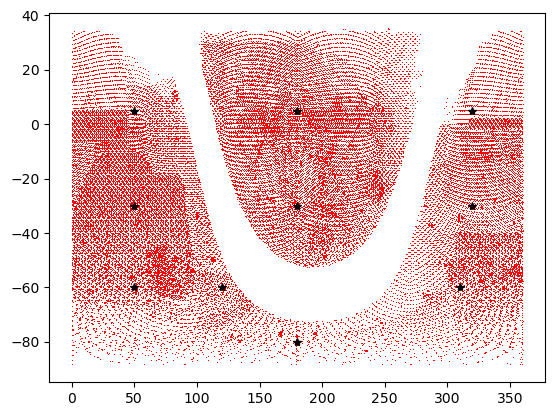

In [6]:
pl.plot(tab['ra'],tab['dec'], 'r,')
pl.plot(test_ra, test_dec, 'k*')

In [7]:
# Put pointings and test points onto the sphere
degree = np.pi / 180.
cra = np.cos(tab['ra']*degree)
sra = np.sin(tab['ra']*degree)
cdec = np.cos(tab['dec']*degree)
sdec = np.sin(tab['dec']*degree)
xyz = np.vstack( (cdec * cra, cdec*sra, sdec)).T

decam_tree = KDTree(xyz)


cra = np.cos(test_ra*degree)
sra = np.sin(test_ra*degree)
cdec = np.cos(test_dec*degree)
sdec = np.sin(test_dec*degree)
test_xyz = np.vstack( (cdec * cra, cdec*sra, sdec)).T

In [8]:
# Find the matches for each test point
ii = decam_tree.query_ball_point(test_xyz, r=1.1*degree)
matches = [tab[ii[j]] for j in range(len(ii))]


In [9]:
def sigma_pm(mjd, sigma_x):
    # Return the uncertainty in slope (proper motion) of a fit
    # to data with times at `mjd` and 1d position error of `sigma_x`
    # at each time.
    # Ignoring any degeneracy with parallax.
    t = (mjd - np.mean(mjd)) / 365.25   # Convert to years.
    # Make Fisher matrix for fit to position and slope
    design = np.vstack( (np.ones_like(t), t)).T
    fisher = np.einsum('ij, i, ik->jk', design, 1./(sigma_x*sigma_x), design)
    # Return slope std dev after marginalization over position
    cov = np.linalg.inv(fisher)
    return np.sqrt(cov[1,1]) 

In [10]:
# Test case for above
mjd = np.linspace(0., 10*365, 100)
sig = np.ones_like(mjd) * 5   # 5 mas per measurement, 100 measures, 10 yrs
print(sigma_pm(mjd,sig), 5 / 10 * np.sqrt(12/100))

0.17159905739748543 0.17320508075688773


In [11]:
def sigma_decam(band, fwhm, teff, imag, turb=8):
    '''Estimate astrometric uncertainty per axis (in mas) for a DECam exposure.
    band = filter band (g/r/i/z)
    fwhm = PSF fwhm in arcsec
    teff = effective exposure time
    imag = magnitude(s) in i band
    turb = turbulence RMS, in mas'''
    
    # Very simple scaling to the 5-sigma values in Alex's proposal table
    m5 = {'g':24.3, 'r':24.1, 'i':23.5, 'z':22.85}
    color = {'g':4.14-5.17, 'r':4.14-4.45, 'i':0, 'z':4.14-4.01} # solar i-x colors
    zp = {'g':31.43, 'r':31.64, 'i':31.63, 'z':31.41}  # mag for 1 e in 90 s
    
    # Signal-to-noise ratio from background
    sn = np.sqrt(teff / 90.) * 5 * 10**(0.4*(m5[band]-(imag-color[band])))
    
    # Make a crude guess at the noise level from star's shot noise
    ### teff has a factor of psf size in it which shouldn't really be here:
    adu = 10**(0.4*(zp[band] - (imag-color[band]))) * (teff / 90.)
    # add in quadrature to bg noise:
    sn = (sn**-2 + 1/adu)**(-0.5)
    # Simple guess is sigma_psf / (s/n)
    sig = np.sqrt(2.) * fwhm / 2.38 / sn * 1000.  # in mas
    return np.hypot(sig, turb)

def decam_obs(tab, mag, turb=12):
    '''Produce mjd, sigma_x arrays for stars of given mags.
    Input table is the exposure table'''
    mjd = []
    sig = []
    for exposure in tab:
        mjd.append(exposure['mjd'])
        sig.append(sigma_decam(exposure['filter'], exposure['fwhm'], 
                               exposure['teff']*exposure['exptime'],
                               mag,
                               turb=turb))
    return np.array(mjd), np.vstack(sig).T
        
    

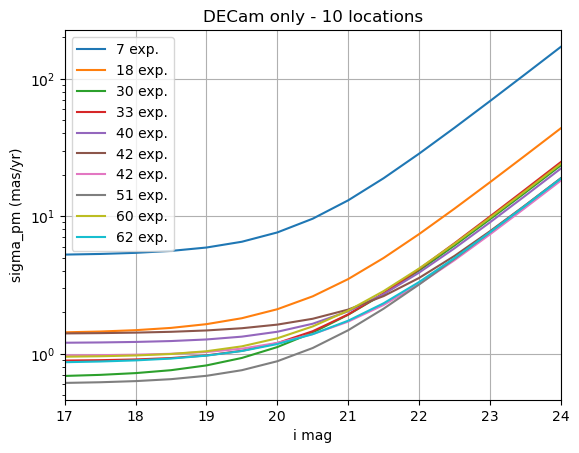

In [12]:
imag = np.arange(17,24.1,0.5)
nn = np.array([len(t) for t in matches])
order = np.argsort(nn)
for i in order:
    t = matches[i]
    mjd, sig = decam_obs(t,imag, turb=12)
    spm = [sigma_pm(mjd, sig[i]) for i in range(len(imag))]
    pl.semilogy(imag, spm, label=str(len(t))+' exp.')
pl.grid()
pl.legend(loc=2)
pl.xlim(17,24)
pl.xlabel('i mag')
pl.ylabel('sigma_pm (mas/yr)')
pl.title('DECam only - 10 locations')
pl.savefig('tmp.png')

In [13]:
# Look at Vernon's table
ret = Table.read('RetIIPM_COADD_MAG.fits')
retg = Table.read('RetIIPM_COADD_MAG_GAIA.fits')
ret.columns

<TableColumns names=('RA_1','DEC_1','MAG_AUTO_G','MAG_AUTO_R','idx','mtype','xi','eta','ra_2','dec_2','pm','pmra','pmdec','parallax','chisqTotal','dof','nClip','c_xx','c_yy','c_vxvx','c_vyvy','c_pipi','c_xy','c_xvx','c_xvy','c_xpi','c_yvx','c_yvy','c_ypi','c_vxvy','c_vxpi','c_vypi','g_mag','r_mag','i_mag','z_mag','Y_mag','g_i_mag','g_n','r_n','i_n','z_n','Y_n','g_spread','r_spread','i_spread','z_spread','Y_spread','g_spread_err','r_spread_err','i_spread_err','z_spread_err','Y_spread_err','Separation')>

In [14]:
# Note Gaia G_sun = 4.78, so solar G-i=0.74.
Gi = 0.74
'''The median proper motion uncertainties are 0.02-0.03 mas/yr for G<15, 
0.07 mas/yr at G=17, 0.5 mas/yr at G=20, and 1.4 mas/yr at G=21 mag.'''

# But also looking at Fig 2 of Gaia DR3 paper there is a plot for DR5 projections
# https://doi.org/10.1051/0004-6361/202243940
dr5_G=np.array([8.,13., 14., 16., 18., 20., 21.])
dr5_sigpm = np.array([0.0018, 0.0018, 0.0025, 0.006, 0.02, 0.08, 0.2])
dr3_sigpm = np.array([0.018, 0.016, 0.014, 0.044,0.123,0.487,1.445])

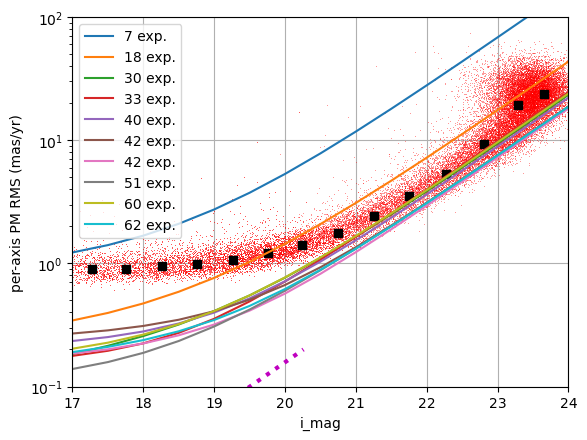

In [15]:
gg = np.concatenate( (ret['g_mag'], retg['g_mag']))
rr = np.concatenate( (ret['r_mag'], retg['r_mag']))
ii = np.concatenate( (ret['i_mag'], retg['i_mag']))
gi = gg - ii
xx = np.concatenate( (ret['c_vxvx'], retg['c_vxvx']))
yy = np.concatenate( (ret['c_vyvy'], retg['c_vyvy']))
xy = np.concatenate( (ret['c_vxvy'], retg['c_vxvy']))
ispr = np.array(np.concatenate((ret['i_spread'],retg['i_spread'])))
star = ispr<0.003
sigpm = (xx*yy-xy*xy)**(0.25) * 1000
gg = np.array(gg)
rr = np.array(rr)
ii = np.array(ii)
sigpm = np.array(sigpm)
pl.semilogy(ii[star], sigpm[star], 'r,', alpha=0.4)
pl.xlim(17,24)
pl.grid()
m = np.arange(17,24,0.5)

for mm in m:
    use = np.logical_and(ii>mm, ii<=mm+0.5)
    use = np.logical_and(use, ispr<0.003)
    i = np.median(ii[use])
    sig = np.median(sigpm[use])
    pl.plot(i,sig,'ks')
pl.xlabel('i_mag')
pl.ylabel('per-axis PM RMS (mas/yr)')


nn = np.array([len(tab) for tab in matches])
order = np.argsort(nn)
for i in order:
    t = matches[i]
    mjd, sig = decam_obs(t,imag, turb=2) #### ???? 12)
    spm = [sigma_pm(mjd, sig[i]) for i in range(len(imag))]
    pl.semilogy(imag, spm, label=str(len(t))+' exp.')
pl.legend(loc=2)

# Plot Gaia
pl.semilogy(dr5_G - Gi, dr5_sigpm, 'm:', lw=3)
pl.ylim(0.1,100)
    
pl.savefig('tmp.png')

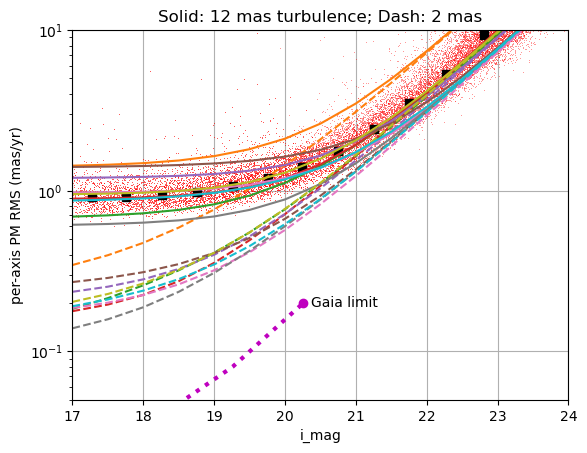

In [16]:
# Plot again showing gain of lower DES turbulence
gg = np.concatenate( (ret['g_mag'], retg['g_mag']))
rr = np.concatenate( (ret['r_mag'], retg['r_mag']))
ii = np.concatenate( (ret['i_mag'], retg['i_mag']))
gi = gg - ii
xx = np.concatenate( (ret['c_vxvx'], retg['c_vxvx']))
yy = np.concatenate( (ret['c_vyvy'], retg['c_vyvy']))
xy = np.concatenate( (ret['c_vxvy'], retg['c_vxvy']))
ispr = np.array(np.concatenate((ret['i_spread'],retg['i_spread'])))
star = ispr<0.003
sigpm = (xx*yy-xy*xy)**(0.25) * 1000
gg = np.array(gg)
rr = np.array(rr)
ii = np.array(ii)
sigpm = np.array(sigpm)
pl.semilogy(ii[star], sigpm[star], 'r,', alpha=0.4)
pl.xlim(17,24)
pl.grid()
m = np.arange(17,24,0.5)

for mm in m:
    use = np.logical_and(ii>mm, ii<=mm+0.5)
    use = np.logical_and(use, ispr<0.003)
    i = np.median(ii[use])
    sig = np.median(sigpm[use])
    pl.plot(i,sig,'ks')
pl.xlabel('i_mag')
pl.ylabel('per-axis PM RMS (mas/yr)')

# Get matplotlib's color cycle:
prop_cycle = pl.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

nn = np.array([len(tab) for tab in matches])
order = np.argsort(nn)
for j,i in enumerate(order):
    t = matches[i]
    if len(t)<17:
        continue
    mjd, sig = decam_obs(t,imag, turb=12)
    spm = [sigma_pm(mjd, sig[i]) for i in range(len(imag))]
    pl.semilogy(imag, spm, label=str(len(t))+' exp.', color=colors[j])
    mjd, sig = decam_obs(t,imag, turb=2)
    spm = [sigma_pm(mjd, sig[i]) for i in range(len(imag))]
    pl.semilogy(imag, spm, label=str(len(t))+' exp.', color=colors[j],linestyle='--')

# Plot Gaia
pl.semilogy(dr5_G - Gi, dr5_sigpm, 'm:', lw=3)
pl.semilogy((dr5_G-Gi)[-1],dr5_sigpm[-1], 'mo')
pl.text((dr5_G-Gi)[-1]+0.1,dr5_sigpm[-1], 'Gaia limit', ha='left', va='center')
pl.ylim(0.05,10)
pl.title('Solid: 12 mas turbulence; Dash: 2 mas')    
pl.savefig('tmp.png')

Note LSST forecasts from 2012 in this paper https://arxiv.org/pdf/1201.5140.pdf
give a floor for sigpm of 0.15 mas/yr at r<20.5, to 1.5 mas/yr at r=24.  

If there are 800 observations in 10 yrs with 2 mas floor, that will give 0.024 mas/yr floor instead!  Well below Gaia DR5 at G=21, but G=21 may not be reaching the LSST noise floor yet.

# LSST data from Daniel
Daniel's mock survey begins about 10/1/2023.  Add 2 years = 730 days to MJD.
Columns in his arrays are (MJD, sigma_pm (arcsec), color)

In [17]:
dd = datetime(2023,10,1)
mjd0 = Time(dd, format='datetime').mjd + 730  # Start of survey
def lsst_data(point, imag, years=10.,turb=2.):
    '''Retrieve list of mjd's and sigma_x for designated initial years
    of LSST survey at chosen imag and location.'''
    a = np.load('Star_detections/Point_{:02d}_i_mag{:02d}.npy'.format(point,int(imag)))
    mjd = np.array(a[:,0]) + 730
    sigx = np.array(a[:,1]) * 1000. # change to mas
    use = mjd < mjd0 + years*365.25
    return mjd[use], np.hypot(sigx[use],turb)
        
#mjd,sigpm = lsst_data(0,18)
#pl.plot(mjd,'r,')

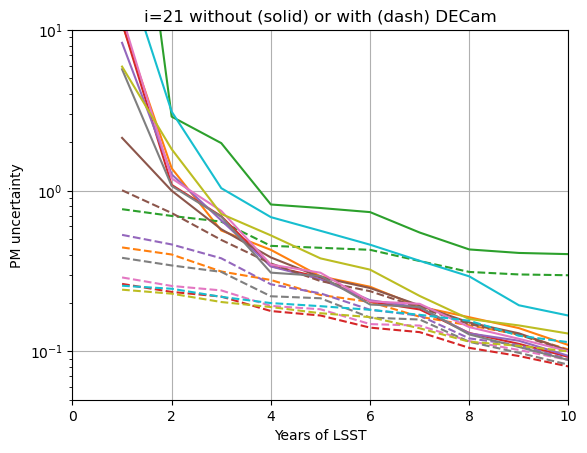

In [18]:
# Plot PM errors vs LSST survey time at fixed mag
# With and without DECam
ii = 21
index = np.where(imag==ii)[0][0]
yrs = np.arange(1,11)

for point in range(10):
    cat_decam = matches[point]
    if len(cat_decam)<17:
        continue
        
    mjd_decam, sigx_decam = decam_obs(cat_decam,imag, turb=2)
    sigx_decam = sigx_decam[index,:]

    sigpm = []
    sigpm_decam = []
    for y in yrs:
        mjd, sigx = lsst_data(point, ii, years=y)
        sigpm.append(sigma_pm(mjd, sigx))
        sigpm_decam.append(sigma_pm(np.concatenate( (mjd, mjd_decam)),
                                    np.concatenate( (sigx, sigx_decam))))
    pl.semilogy(yrs, sigpm, color=colors[point], linestyle='-')
    pl.semilogy(yrs, sigpm_decam, color=colors[point], linestyle='--')
    
pl.xlim(0,10)
pl.ylim(0.05,10.)
pl.xlabel('Years of LSST')
pl.ylabel('PM uncertainty')
pl.title('i={:d} without (solid) or with (dash) DECam'.format(ii))
pl.grid()
pl.savefig('tmp.png')

In [19]:
# I'll calculate the PM uncertainty for all combinations of data
points = np.where( np.array([len(t) for t in matches]) > 15)[0]
imag = np.arange(16,25)
yrs = np.arange(0,11)
npts = len(points)
nmag = len(imag)
nyr = len(yrs)

sigpm_lsst = np.zeros( (npts, nmag, nyr), dtype=float)
sigpm_dec = sigpm_lsst.copy()

In [ ]:
imag_dec = np.arange(16,25,0.5)
print(imag)
for j,pp in enumerate(points):
    cat_dec = matches[pp]
    mjd_dec, sigx_dec = decam_obs(cat_dec,imag_dec, turb=2)   ### Adjust turbulence here
        
    for k,ii in enumerate(imag):
        index = np.where(imag_dec==ii)[0][0] 
        sigx_decam = sigx_dec[index,:]  # Get the desired mag

        for l,yy in enumerate(yrs):
            if yy==0.:
                # Only have results with DECam for y==0
                sigpm_dec[j,k,l] = sigma_pm(mjd_dec, sigx_decam)
            else:
                # Calculate sigpm with and without DECam
                mjd, sigx = lsst_data(pp, ii, years=yy, turb=2.)
                sigpm_lsst[j,k,l] = sigma_pm(mjd, sigx)
                sigpm_dec[j,k,l] = sigma_pm(np.concatenate( (mjd, mjd_dec)),
                                            np.concatenate( (sigx, sigx_decam)))

# Take medians over sky locations
med_lsst = np.median(sigpm_lsst, axis=0)
med_dec = np.median(sigpm_dec, axis=0)

[16 17 18 19 20 21 22 23 24]


In [23]:
# Save data used for plots
np.savez('pm_plot', imag_dec=imag_dec, imag=imag, dr5_G=dr5_G, Gi=Gi,
        dr5_sigpm=dr5_sigpm,
        dr3_sigpm=dr3_sigpm,
        med_lsst=med_lsst,
        med_dec=med_dec)

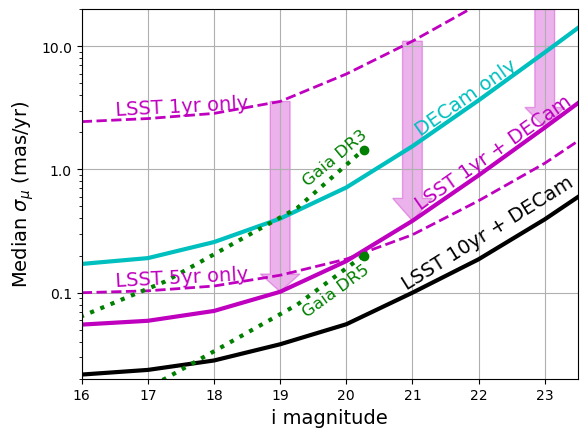

In [24]:
# Try plotting the medians among points
fontsize=14


# DECam only
pl.semilogy(imag, med_dec[:,0], 'c-', lw=3, label = 'DECam')
pl.text(21, med_dec[5,0]*1.15, 'DECam only', 
        color='c', fontsize=fontsize, rotation=35, ha='left',va='bottom')

# LSST Only
pl.semilogy(imag, med_lsst[:,5], 'm--', lw=2, label = 'LSST 5yr')
pl.text(16.5, med_lsst[0,5]*1.05, 'LSST 5yr only', 
        color='m', fontsize=fontsize, rotation=3, ha='left',va='bottom')
pl.semilogy(imag, med_lsst[:,1], 'm--', lw=2, label = 'LSST 1yr')
pl.text(16.5, med_lsst[0,1]*1.05, 'LSST 1yr only', 
        color='m', fontsize=fontsize, rotation=3, ha='left',va='bottom')

# LSST + DECam
pl.semilogy(imag, med_dec[:,1], 'm-', lw=3, label = 'LSST 1yr + DECam')
pl.text(21, med_dec[5,1]*1.15, 'LSST 1yr + DECam', 
        color='m', fontsize=fontsize, rotation=35, ha='left',va='bottom')

pl.semilogy(imag, med_dec[:,10], 'k-', lw=3, label = 'LSST 10yr + DECam')
pl.text(20.8, med_dec[5,10]*1.0, 'LSST 10yr + DECam', 
        color='k', fontsize=fontsize, rotation=32, ha='left',va='bottom')


# Plot Gaia
pl.semilogy(dr5_G - Gi, dr5_sigpm, 'g:', lw=3, label='Gaia DR5')
pl.semilogy((dr5_G-Gi)[-1],dr5_sigpm[-1], 'go')
pl.text(19.3, 0.06, 'Gaia DR5', 
        color='g', fontsize=12, rotation=36, ha='left',va='bottom')

pl.semilogy(dr5_G - Gi, dr3_sigpm, 'g:', lw=3, label='Gaia DR3')
pl.semilogy((dr5_G-Gi)[-1],dr3_sigpm[-1], 'go')
pl.text(19.3, 0.7, 'Gaia DR3', 
        color='g', fontsize=12, rotation=40, ha='left',va='bottom')

# Put numbers on y axis
pl.gca().yaxis.set_major_formatter(ScalarFormatter())

pl.xlim(16,23.5)
pl.ylim(0.02,20)
#pl.legend(loc=2)
pl.xlabel('i magnitude', fontsize=fontsize)
pl.ylabel(r'Median $\sigma_\mu$ (mas/yr)', fontsize=fontsize)
pl.grid()
#pl.arrow(19,med_lsst[1,2],0,med_dec[1,1]-med_lsst[1,2], 
pl.arrow(19,med_lsst[3,1],0,med_dec[3,1]-med_lsst[3,1], 
         width=0.3,
         length_includes_head=True,
         head_length=0.04,
         head_width=0.6,
         alpha=0.3,color='m')

#pl.arrow(21,med_lsst[3,2],0,med_dec[3,1]-med_lsst[3,2], 
pl.arrow(21,med_lsst[5,1],0,med_dec[5,1]-med_lsst[5,1], 
         width=0.3,
         length_includes_head=True,
         head_length=0.2,
         head_width=0.6,
         alpha=0.3,color='m')

#pl.arrow(23,med_lsst[5,2],0,med_dec[5,1]-med_lsst[5,2], 
pl.arrow(23,med_lsst[7,1],0,med_dec[7,1]-med_lsst[7,1], 
         width=0.3,
         length_includes_head=True,
         head_length=1,
         head_width=0.6,
         alpha=0.3,color='m')
pl.savefig('pm_vs_mag.pdf')




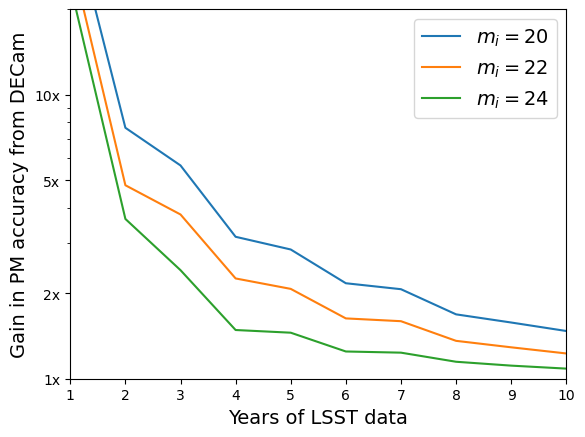

In [25]:
# Try a plot of DECam gain vs time
gain = np.median(sigpm_lsst[:,:,1:] / sigpm_dec[:,:,1:], axis=0)
pl.plot(yrs[1:], gain[2,:], label='$m_i=20$')
pl.plot(yrs[1:], gain[4,:], label='$m_i=22$')
pl.plot(yrs[1:], gain[6,:], label='$m_i=24$')
pl.legend(loc=1, fontsize=fontsize)

pl.gca().set_yscale('log')
pl.gca().yaxis.set_major_formatter(ScalarFormatter())
pl.xlim(1,10)
pl.ylim(1,20)
pl.xlabel('Years of LSST data', fontsize=fontsize)
pl.ylabel('Gain in PM accuracy from DECam', fontsize=fontsize)
pl.gca().yaxis.set_ticks([1,2,5,10])

pl.gca().yaxis.set_ticklabels(['1x','2x','5x','10x'])
pl.savefig('gain_vs_time.pdf')